In [83]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv


In [84]:
import numpy as np
import pandas as pd
import time

In [85]:
df = pd.read_csv("/kaggle/input/datasets/nani123456789/social-network-ads/Social_Network_Ads.csv")

In [86]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [87]:
df = df[['Age', 'Purchased','EstimatedSalary']]


In [88]:
df.head()

,Age,Purchased,EstimatedSalary
0,19,0,19000
1,35,0,20000
2,26,0,43000
3,27,0,57000
4,19,0,76000


In [89]:
x = df.drop("Purchased", axis = 1)
y = df["Purchased"]

In [90]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [91]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [92]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaler = scaler.fit_transform(x)

In [94]:
from sklearn.model_selection import train_test_split
X_train, X_test,Y_train,Y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [95]:
X_train.shape

(320, 2)

In [96]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [97]:
model = Sequential()

model.add(Dense(10, activation = 'relu', input_dim  = 2))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

Batch G.D


In [128]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])
start = time.time()
history = model.fit(X_train, Y_train, epochs = 80,verbose = 0, batch_size = 320,validation_split = 0.2) #batch_size = 1
print(time.time() - start)

8.550406217575073


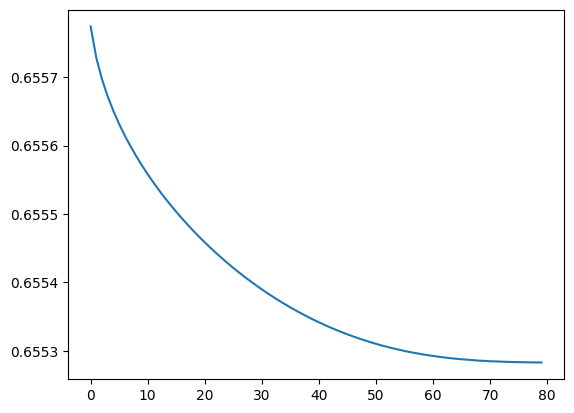

In [129]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

Stochiastic G.D


In [134]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])
start = time.time()
history = model.fit(X_train, Y_train, epochs = 500, batch_size = 320, verbose = 0,validation_split = 0.2) #batch_size = 1
print(time.time() - start)

50.27488374710083


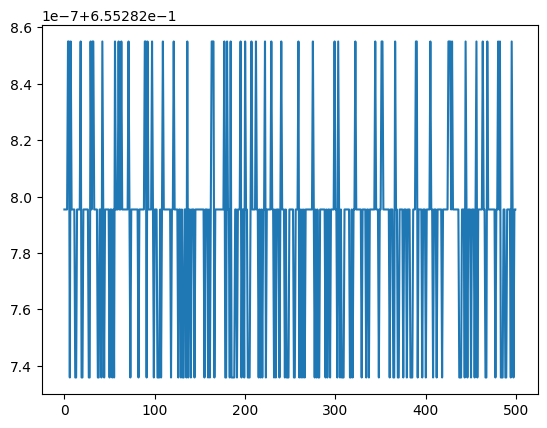

In [135]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [ ]:
Mini Batch G.D


In [130]:
model.compile(loss = 'binary_crossentropy', metrics = ['accuracy'])
start = time.time()
history = model.fit(X_train, Y_train, epochs = 10, batch_size = 100, validation_split = 0.2) #batch_size = 1
print(time.time() - start)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.6321 - loss: 0.6579 - val_accuracy: 0.7188 - val_loss: 0.6092
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6459 - loss: 0.6502 - val_accuracy: 0.7188 - val_loss: 0.6090
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6459 - loss: 0.6501 - val_accuracy: 0.7188 - val_loss: 0.6091
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6471 - loss: 0.6495 - val_accuracy: 0.7188 - val_loss: 0.6091
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6334 - loss: 0.6572 - val_accuracy: 0.7188 - val_loss: 0.6091
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6396 - loss: 0.6537 - val_accuracy: 0.7188 - val_loss: 0.6091
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6434 - loss: 0.6515 - val_accuracy: 0.7188 - val_loss: 0.6091
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6446 - loss: 0.6508 - val_accuracy: 0.7188 - val_loss: 0.6092

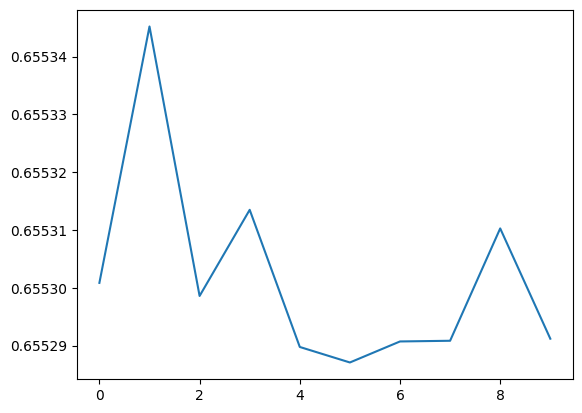

In [131]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])